# Duo Dancing Improvisation Session Plots

For laughter and dance paper. 

Compose plots of heart rate, jerk, motion conditions and laughter annotations. 

Audio and Video not public. Event and timing information in this repo's datain folder.

Physiology measurements in OSF repository  Hybrid Dance: Remote Improvisation in Telematic Environments  https://osf.io/sfc7t/overview

In [1]:
import os
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg

import librosa
from scipy import interpolate

In [1]:
import sys
import os
import time
import datetime as dt
import pytz
from pytz.reference import UTC 
import math
import numpy as np 
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
import heartpy as hp

import json 
import librosa
from IPython.display import Audio
import mir_eval.sonify


from scipy.signal import butter, filtfilt, argrelextrema
from scipy import interpolate
from scipy.interpolate import interp1d

from pydub import AudioSegment
from matplotlib.transforms import ScaledTranslation



In [2]:
%load_ext autoreload
%autoreload 1
%aimport eq
%aimport mh
%aimport viz

In [3]:
 %reload_ext autoreload

# Import data constellation

In [4]:
Event = 'DanceImprov'
audio_loc='../DanceImprov/Video_Rehearsals/'
phys_dir ='../DanceImprov/Aligned/Physio/Segments/'
misc_loc = './datain/'
plot_loc = './plots/'
Row_Order = ['Lisa','Ole'] #, 'VN203'
audiofiles = ['Colocated_Reh.wav','Lola_Reh.wav','Zoom2_Reh.wav']
offsets = {'Colocated':1.519, 'Zoom2':23.004 , 'LoLa':3.849}
concert_name = {'Colocated':'Co-located','Zoom2':'Zoom','Lola':'LoLa'}

player_labels = {'Lisa':'Dancer 2','Ole':'Dancer 1'}


segmentationfiles = {'Colocated':'CoLocated_Rehearsal_Panasonic_Cut_25fps_Segmentation.csv',
                   'Lola': 'LoLa_SidebySide_Rehearsal_Panasonic_25fps_Segmentation.csv',
                   'Zoom2':'30Zoom_SidebySide_Rehearsal_Panasonic_25fps_Segmentation.csv'}

annotationfiles = {'Colocated':'CoLocated_Rehearsal_Panasonic_Cut_25fps_labelled_updated.csv',
                   'Lola': 'LoLa_SidebySide_Rehearsal_Panasonic_25fps_labelled_updated.csv',
                   'Zoom2':'30Zoom_SidebySide_Rehearsal_Panasonic_25fps_labelled_updated.csv'}

df_files = pd.DataFrame(columns=['PartID','Performance','Location','Segment','Signal','Measure','FileLoc'])
k = 0
for path, subdirs, files in os.walk(phys_dir):
    for f in files:
        fileloc = os.path.join(path, f)
        dets = f.split('_')
        measure = dets[-1]
        if measure.endswith('.csv'):
            # print(f)
            measure = measure[:-4]
            signal = measure[-3:]
            if signal == 'ATA': signal = 'DATA'
            if signal == 'ESP': signal = 'RESP'
            if len(dets)==6:
                    df_files.loc[k,:] = {'PartID':dets[0],'Performance':dets[1],'Location':dets[2],'Segment':dets[3],'Signal':signal,'Measure':measure,'FileLoc':fileloc}
                    k+=1
PhysFiles = df_files.copy()

In [5]:
concerts = ['Colocated','Zoom2','Lola'] #

for concert in concerts:
    print(concert)
    subfiles = PhysFiles.query('Performance==@concert')
    print(subfiles.Segment.unique())

Colocated
['Rehearsal' 'Warmup' 'Performance3' 'Performance1' 'Performance2']
Zoom2
['Performance1' 'Warmup' 'Rehearsal']
Lola
['Warmup' 'Performance1' 'Rehearsal']


In [6]:
df_allfeats = {}

subfiles = PhysFiles.query('Performance==@concert and Segment==@Event')
Row_Order = ['Lisa','Ole']
players = Row_Order
player_labels = {'Lisa':'Dancer 2','Ole':'Dancer 1'}
collist = ['Lisa','Ole']
alist = ['Lisa','Ole']
i=0
# Motion
time_c = 'c_sTime'

In [7]:
Events = ['Rehearsal','Performance1']
offsets = {'ColocatedRehearsal':1.519, 'Zoom2Rehearsal':23.004 , 'LolaRehearsal':3.849,
           'ColocatedPerformance1':47.0, 'Zoom2Performance1':-1.0 , 'LolaPerformance1':4.0}

concert_dur = {'ColocatedRehearsal':3375.0,'Zoom2Rehearsal':2940.0,'LolaRehearsal':2547.0,
              'ColocatedPerformance1':448.0,'Zoom2Performance1':560.0,'LolaPerformance1':860.0}

for concert in concerts:
    for Event in Events:
        print([concert,Event])
        shift_s = offsets[concert+Event]
        altT = np.arange(0, concert_dur[concert+Event],0.1) # Colocated 0.01 
        df = pd.DataFrame(index = altT, columns = collist) #Row_Order)
        if concert =='LoLa':concert = 'Lola'
        subfiles = PhysFiles.query('Performance==@concert and Segment==@Event')
        sig = 'ACC'
        subfiles = PhysFiles.query('Performance==@concert and Segment==@Event and Signal==@sig').copy()
        subfiles.set_index('PartID',inplace=True)
        for partID,row in subfiles.iterrows(): 
            V = pd.read_csv(row['FileLoc'],skipinitialspace=True)
            temp_df = pd.DataFrame(index=altT)
            V[time_c] = V[time_c]-shift_s
            times = V[time_c]
            for c in ['Vert Accelerometer','Lat Accelerometer','Long Accelerometer']:
                f = interpolate.interp1d(times,V['Vert Accelerometer'].rolling(int(256*0.05)).mean(),kind = 'linear')    
                temp_df.loc[:,c] = f(altT)
                
            df.loc[:,partID] =  np.sqrt(np.square(temp_df.loc[:,[ 'Vert Accelerometer','Lat Accelerometer','Long Accelerometer']].diff()).sum(axis=1))
        t ='ACC_QoM'
        df_allfeats[concert+Event+t] = df.copy()

        # heart rate
        df_feats = pd.DataFrame(index = altT,columns = collist)
        sig = 'normHR1bt'
        # sig = 'HR10bt'
        meas = 'altEQCIBI'
        subfiles = PhysFiles.query('Performance==@concert and Segment==@Event and Measure==@meas').copy()
        subfiles.set_index('PartID',inplace=True)
        
        for partID,row in subfiles.iterrows(): #altEQCIBI
            V = pd.read_csv(row['FileLoc'])  # currently this defaults to altEQCIBI before the original signal
            V[time_c] = V[time_c]#-shift_s
            V = V.loc[V['Interbeat Interval (MS)']>0,:].copy()
            if len(V)>10:
                sig_t = V[time_c]
                sig_v = V['Interbeat Interval (MS)']
                IBI = mh.clean_IBI(sig_t,sig_v,activitytype='resp')
                HR = mh.ibi_feats(IBI.index,IBI.IBI.values,altT)
                df_feats.loc[:,partID] = HR[sig].values
        
        df_allfeats[concert+Event+sig] = df_feats.copy()

        df_smoothed = df_feats.copy()
        for partID in Row_Order:
            HR = df_smoothed[partID]
            cutHR = HR[HR.notna()]
            cutT = HR[HR.notna()].index
            f = interpolate.interp1d(cutT,cutHR.values,fill_value='extrapolate',kind= 'linear')
            df_smoothed[partID] = f(df_smoothed.index)
        df_smoothed = df_smoothed.where(df_smoothed>-0.2, other=-0.2 ) #df[:] = np.where( mask, 30, df ) 
        df_smoothed = df_smoothed.where(df_smoothed<1.5, other=1.5) #df[:] = np.where( mask, 30, df ) 
        df_allfeats[concert+Event+'normHR1bt_smoothed'] = df_smoothed.copy()

['Colocated', 'Rehearsal']
['Colocated', 'Performance1']
['Zoom2', 'Rehearsal']
['Zoom2', 'Performance1']
['Lola', 'Rehearsal']
['Lola', 'Performance1']


In [12]:
events_types = ['Search','Clean','Rehearse','Perform','Verbal']
eventType_code = dict(zip(events_types,['S','C','R','P','V']))
code_eventType =  dict(zip(['S','C','R','P','V'],events_types))
player_labels = {'Lisa':'Dancer 2','Ole':'Dancer 1'}
player_pallet = {'Dancer 1':[0.5,0.5,0.5], 'Dancer 2':'k'}

events_types = ['Verbal','Search','Clean','Rehearse','Perform',]
eventType_pallet=dict(zip(events_types,['#eddca5','#c99b38','#8fb7b7','#8fb7b7','#00b0be']))
eventType_hatch=dict(zip(events_types,['x','*','\\','.',None,]))

In [8]:
event_lists = {}

for concert in concerts:
    Event = 'Rehearsal'
    Event_timings = pd.read_csv(misc_loc +segmentationfiles[concert],skiprows=1)
    dancings = pd.DataFrame()
    dancings['TIME'] = Event_timings['Begin Time - ss.msec']
    dancings['DURATION'] = Event_timings['Duration - ss.msec']
    dancings['LABEL'] = Event_timings['Seg_code']
    event_lists[concert+Event] = dancings.copy()

In [9]:
for concert in concerts:
    # for Event in Events:
    Event = 'Rehearsal'
    
    aud_file = audio_loc+ concert +'_Cleaned_Reh.wav'
    y, sr = librosa.load(aud_file)
    rms =librosa.feature.rms(y=y, frame_length=256, hop_length=64, center=True, pad_mode='constant')
    times = librosa.times_like(rms,sr = sr, hop_length=64)
    
    buff = 0 # no buffer for this audio
    C = librosa.cqt(y=y, sr=sr)
    C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
    times = (-buff+np.arange(len(C_db[0]))*(times[-1])/len(C_db[0])).round(3) #-shift_s
    pitchticks = np.arange(7,84,12)
    pitchticklabels=['C1','C2','C3','C4','C5','C6','C7']
    C_df = pd.DataFrame(data=C_db).transpose()
    C_df = C_df[C_df.columns[::-1]]
    C_df.set_index(times,inplace = True)
    df_allfeats[concert+Event+'Audio_cqt'] = C_df.copy()

    Event = 'Performance1'
        
    aud_file = audio_loc+ concert +'_Cleaned_Performance.wav'
    y, sr = librosa.load(aud_file)
    rms =librosa.feature.rms(y=y, frame_length=256, hop_length=64, center=True, pad_mode='constant')
    times = librosa.times_like(rms,sr = sr, hop_length=64)
    
    buff = 0 # no buffer for this audio
    C = librosa.cqt(y=y, sr=sr)
    C_db = librosa.amplitude_to_db(np.abs(C), ref=np.max)
    times = (-buff+np.arange(len(C_db[0]))*(times[-1])/len(C_db[0])).round(3)
    pitchticks = np.arange(7,84,12)
    pitchticklabels=['C1','C2','C3','C4','C5','C6','C7']
    C_df = pd.DataFrame(data=C_db).transpose()
    C_df = C_df[C_df.columns[::-1]]
    C_df.set_index(times,inplace = True)
    df_allfeats[concert+Event+'Audio_cqt'] = C_df.copy()


In [14]:
Laughters = {}
for concert in concerts:

    Event_timings = pd.read_csv(misc_loc +segmentationfiles[concert],skiprows=1)
    dancings = pd.DataFrame()
    dancings['TIME'] = Event_timings['Begin Time - ss.msec']
    dancings['DURATION'] = Event_timings['Duration - ss.msec']
    dancings['LABEL'] = Event_timings['Seg_code']
    events_types = ['Search','Clean','Rehearse','Verbal']
    sub_eventTypes = list(dancings.LABEL.str[0].unique()) 
    b = list(set(code_eventType.keys()) & set(sub_eventTypes))
    
    eventType_code = dict(zip(events_types,['S','C','R','V']))
    code_eventType =  dict(zip(['S','C','R','V'],events_types))
    print(list(dancings.LABEL.unique()) )
    sub_eventTypes = list(dancings.LABEL.str[0].unique()) 
    b = list(set(['S','C','R','V']) & set(sub_eventTypes))
    print(b)
    con_cols =  {}
    for ev in b: con_cols[ev] = (concert[:2] +'_'+ code_eventType[ev])
    
    # for e in sub_eventTypes: 
    #     if e in code_eventType.keys():
    #         ev = code_eventType[e]
    #         ax.axvspan(-1,-0.5, facecolor=event_pallet[ev],hatch=event_hatch[ev],edgecolor="w",alpha = 0.5,label=ev)
    
    annotates = pd.read_csv(misc_loc +annotationfiles[concert],skiprows=1)
    LLs = annotates['Laughter'].unique()
    
    laughs = pd.DataFrame(columns = ['TIME', 'DURATION', 'LABEL', 'Who', 'Mistake', 'Negotiation','Difficulty', 'Novelty', 'Joyful', 'Joke', 'Other'])
    print(LLs[0])
    
    for i in range(1,len(LLs)):
        L = LLs[i]
        Ls = annotates.query('Laughter==@L')
        laughs.loc[i, 'TIME'] = Ls['Begin Time - ss.msec'].min()
        laughs.loc[i, 'TIMEND'] = Ls['End Time - ss.msec'].max()
        laughs.loc[i, 'DURATION'] = Ls['End Time - ss.msec'].max() - Ls['Begin Time - ss.msec'].min()
        laughs.loc[i, 'LABEL'] = L.lower()
    
    laughs['Who'] = ''
    laughs.loc[laughs.query('LABEL.str.contains("solo") and LABEL.str.contains("ole")').index,'Who'] = 'Dancer 1'
    laughs.loc[laughs.query('LABEL.str.contains("solo") and LABEL.str.contains("lisa")').index,'Who'] = 'Dancer 2'
    laughs.loc[laughs.query('LABEL.str.contains("contag")').index,'Who'] = 'contagious'
    laughs.loc[laughs.query('LABEL.str.contains("simultan")').index,'Who'] = 'simultaneous'
    
    #Mistake 	Negociation 	Communicating difficulty 	Novelty and Surprise 	Joyful 	Verbal Joke
    laughs['Mistake'] = 0 # Mistakes and Confusion (labels: mistake, confusion) ,
    laughs.loc[laughs.query('LABEL.str.contains("mistake")').index ,'Mistake'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("confusion")').index ,'Mistake'] = 1
    laughs['Negotiation'] = 0 # Negotiation (label: agreement, disagreement, negotiation),
    laughs.loc[laughs.query('LABEL.str.contains("agreement")').index ,'Negotiation'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("disagreement")').index ,'Negotiation'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("negotiation")').index ,'Negotiation'] = 1
    
    laughs['Difficulty'] = 0 # Communicating difficulty level (label: difficulty level)
    laughs.loc[laughs.query('LABEL.str.contains("difficult")').index ,'Difficulty'] = 1
    
    laughs['Novelty'] = 0 # Novelty and Surprise (label: Novelty and Suprise) ,
    laughs.loc[laughs.query('LABEL.str.contains("novelty and suprise")').index ,'Novelty'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("novelty")').index ,'Novelty'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("suprise")').index ,'Novelty'] = 1
    
    laughs['Joyful'] = 0 # Playfulness (label Playfulness )
    laughs.loc[laughs.query('LABEL.str.contains("playful")').index ,'Joyful'] = 1
    laughs.loc[laughs.query('LABEL.str.contains("enjoyment")').index ,'Joyful'] = 1
    
    laughs['Joke'] = 0
    laughs.loc[laughs.query('LABEL.str.contains("joke")').index ,'Joke'] = 1
    
    laughs['Other'] = 1
    laughs.loc[laughs[['Mistake', 'Negotiation', 'Difficulty', 'Novelty', 'Joyful', 'Joke']].sum(axis=1)>0,'Other'] = 0
    
    Laughters[concert] = laughs.copy()


who_hatch = dict(zip(['Dancer 1','Dancer 2', 'contagious','simultaneous'],['\\','//','.',None]))
alt_hatch={'solo':'//', 'group':None}

whats = ['Mistake', 'Negotiation', 'Difficulty', 'Novelty', 'Joyful', 'Joke','Other']
# what_palette = dict(zip(whats,list(sns.color_palette("colorblind",len(whats)))))
what_palette = dict(zip(whats,list(sns.color_palette("bright",len(whats)))))


['S', 'R', 'R_V', 'C', 'V', 'I']
['R', 'C', 'S', 'V']
nan
['S', 'S_ballet', 'S_point', 'S_reaction', 'S_floor', 'S_hands', 'S_sound', 'S_chase', 'S_body', 'S_claps', 'S_still', 'S_imitation', 'S_arms', 'S_breath', 'S_eyes', 'S_call', 'V', 'S_camera', 'I', 'R']
['R', 'S', 'V']
nan
['S_robots', 'S_diss', 'S_updown', 'I', 'S_corners', 'S_hands', 'S_head', 'Break', 'S_floor', 'S_rope', 'V']
['S', 'V']
nan


# Plot Quantity of Motion and Event sequence for all sessions

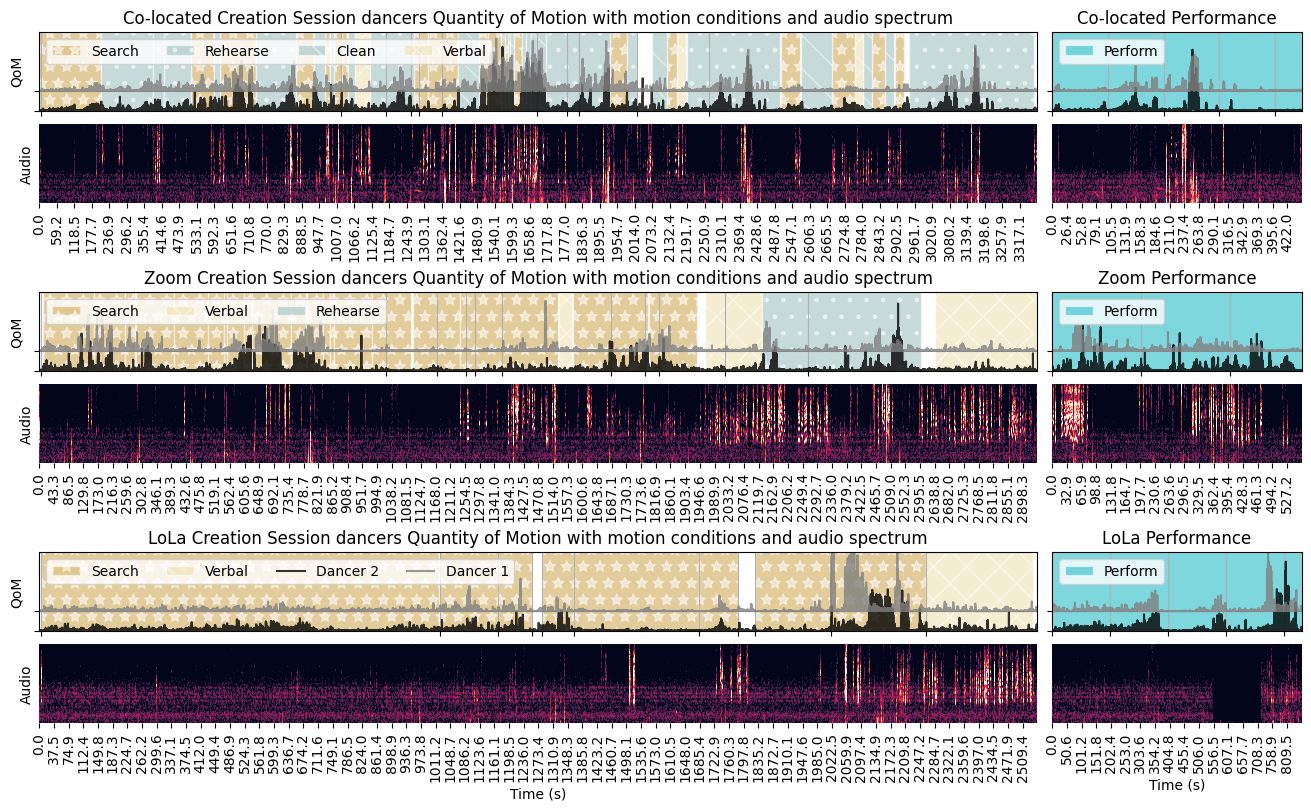

In [25]:
fig3 = plt.figure(constrained_layout=True,figsize=(13,8))
gs = fig3.add_gridspec(6, 5)
axes={}
axes[0] = fig3.add_subplot(gs[0, 0:4])
axes[1] = fig3.add_subplot(gs[0, 4])
axes[2] = fig3.add_subplot(gs[1, 0:4])
axes[3] = fig3.add_subplot(gs[1, 4])
axes[4] = fig3.add_subplot(gs[2, 0:4])
axes[5] = fig3.add_subplot(gs[2, 4])
axes[6] = fig3.add_subplot(gs[3, 0:4])
axes[7] = fig3.add_subplot(gs[3, 4])
axes[8] = fig3.add_subplot(gs[4, 0:4])
axes[9] = fig3.add_subplot(gs[4, 4])
axes[10] = fig3.add_subplot(gs[5, 0:4])
axes[11] = fig3.add_subplot(gs[5, 4])

for i in range(len(concerts)):
    concert = concerts[i]
    Event = 'Rehearsal'
    Event_timings = event_lists[concert+Event].copy()
    s_time = 0
    e_time =  concert_dur[concert+Event]
    
    ax = axes[i*4+0]
    sub_events = Event_timings#.query('TIME+DURATION>=@s_time and TIME<@e_time')
    sub_eventTypes = list(sub_events.LABEL.str[0].unique())
    for e in sub_eventTypes: 
        if e in code_eventType.keys():
            ev = code_eventType[e]
            ax.axvspan(-1,-0.5, facecolor=eventType_pallet[ev],hatch=eventType_hatch[ev],edgecolor="w",alpha = 0.5,label=ev)
    ax.legend(ncol=len(sub_eventTypes),loc='upper left')
    for e in sub_eventTypes: 
        if e in code_eventType.keys():
            ev = code_eventType[e]
            viz.annat_shade(ax,sub_events.query('LABEL.str.startswith(@ev[0])'),eventType_pallet[ev],eventType_hatch[ev],0.5)

    df_feats = df_allfeats[concert+Event+'ACC_QoM'].copy()
    cols = df_feats.columns
    shift_d = 3000
    for counter_i in range(len(alist)):
        partID = alist[counter_i]
        ax.plot(df_feats[partID]+counter_i*shift_d,color=player_pallet[player_labels[partID]],alpha=0.8,label=player_labels[partID])
    if i==2: ax.legend(ncol=len(sub_eventTypes),loc='upper left')
    ax.set(xlim = [s_time,e_time],ylim = [0,4*shift_d],xticks=dancings['TIME'],xticklabels = [],yticks = [0,shift_d],ylabel = 'QoM')
    ax.set(yticklabels=[],title=concert_name[concert]+ ' Creation Session dancers Quantity of Motion with motion conditions and audio spectrum')

    ax.grid()

    ax = axes[i*4+2]
    df = df_allfeats[concert+Event+'Audio_cqt']
    A = df.set_index(np.round(df.index,1),drop=True)
    chart = sns.heatmap(data=A.loc[s_time:e_time,:].transpose(),cmap="rocket",vmin =-70,vmax=-30,ax=ax,cbar = False,fmt='.1f')
    ax.set(yticks=[],ylabel='Audio') 

    ax = axes[i*4+1]
    Event = 'Performance1'
    s_time = 0
    e_time =  concert_dur[concert+Event]
    
    df_feats = df_allfeats[concert+Event+'ACC_QoM'].copy()
    cols = df_feats.columns
    ev = 'Perform'
    ax.axvspan(s_time,e_time, facecolor=eventType_pallet[ev],hatch=eventType_hatch[ev],edgecolor="w",alpha = 0.5,label=ev)
    ax.legend(loc='upper left')
    for counter_i in range(len(alist)):
        partID = alist[counter_i]
        ax.plot(df_feats[partID]+counter_i*shift_d,color=player_pallet[player_labels[partID]],alpha=0.8,label=player_labels[partID])
    # ax.legend(ncol=2,loc='upper left')
    ax.set(xlim = [s_time,e_time],ylim = [0,4*shift_d],yticks = [0,shift_d],xticklabels = []) #,xticks=dancings['TIME'],
    ax.set(yticklabels=[],title=concert_name[concert]+ ' Performance') 
    ax.grid()
    # ax.set_xlabel('Time (s)')

    ax = axes[i*4+3]
    df = df_allfeats[concert+Event+'Audio_cqt']
    A = df.set_index(np.round(df.index,1),drop=True)
    chart = sns.heatmap(data=A.loc[s_time:e_time,:].transpose(),cmap="rocket",vmin =-70,vmax=-30,ax=ax,cbar = False,fmt='.1f')
    ax.set(yticks=[]) 
    
ax.set_xlabel('Time (s)')
axes[i*4+2].set_xlabel('Time (s)')
mydpi  = 192
plt.savefig('./plots/Fig4_DuoDance_Timelines.jpeg',bbox_inches = 'tight',dpi = mydpi)
plt.show()

Now report correlations within and between sections.

# Laughter and Heart Rate plot with Annotations

In [26]:
An = []
# colocated
An.append({'x':508,'y':0.6,'text':'A','xytext':(-18, 15),'axN':1 })
An.append({'x':585,'y':0.8,'text':'B','xytext':(-23, 10),'axN':1 })
An.append({'x':1042,'y':0.7,'text':'C','xytext':(-20, 15),'axN':1 })
An.append({'x':2389,'y':0.75,'text':'D','xytext':(-20, 15),'axN':1 })

# Zoom
An.append({'x':133,'y':0.55,'text':'E','xytext':(-20, 15),'axN':4})
An.append({'x':382,'y':0.75,'text':'F','xytext':(-20, 15),'axN':4})
An.append({'x':853,'y':1.1,'text':'G','xytext':(-23, 10),'axN':4})
An.append({'x':1587,'y':0.55,'text':'H','xytext':(-23, 10),'axN':4})
An.append({'x':1608,'y':0.65,'text':'I','xytext':(-10, 18),'axN':4 })
An.append({'x':1685,'y':0.55,'text':'J','xytext':(-10, 18),'axN':4})
An.append({'x':2028,'y':0.55,'text':'K','xytext':(-20, 15),'axN':4})
An.append({'x':2591,'y':1.1,'text':'L','xytext':(-23, 10),'axN':4})



#LoLa 
An.append({'x':1432,'y':0.55,'text':'M','xytext':(-20, 15),'axN':7 })
An.append({'x':1500,'y':0.55,'text':'N','xytext':(-20, 15),'axN':7 })
An.append({'x':1650,'y':0.55,'text':'O','xytext':(-20, 15),'axN':7 })
An.append({'x':2028,'y':0.55,'text':'P','xytext':(-25, 5),'axN':7 })
An.append({'x':2096,'y':0.75,'text':'Q','xytext':(-20, 15),'axN':7 })

Annotations = pd.DataFrame(An)


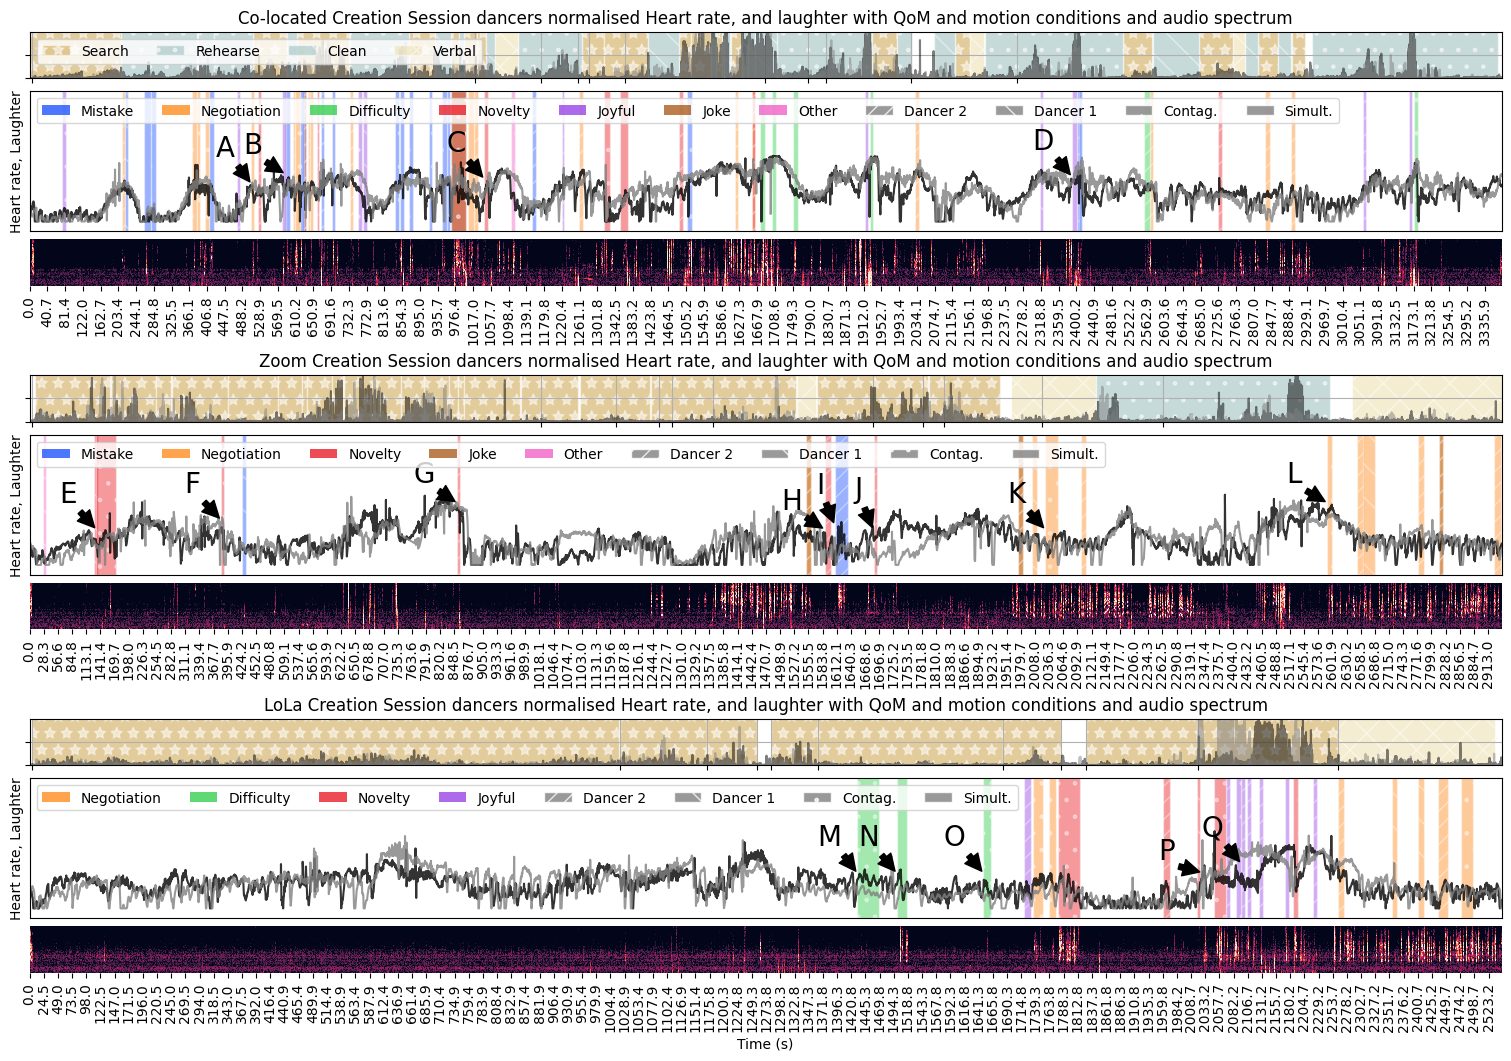

In [27]:
fig3 = plt.figure(constrained_layout=True,figsize=(15,10.5))
gs = fig3.add_gridspec(15, 1)
axes={}
axes[0] = fig3.add_subplot(gs[0, 0])
axes[1] = fig3.add_subplot(gs[1:4, 0])
axes[2] = fig3.add_subplot(gs[4, 0])
axes[3] = fig3.add_subplot(gs[5, 0])
axes[4] = fig3.add_subplot(gs[6:9, 0])
axes[5] = fig3.add_subplot(gs[9, 0])
axes[6] = fig3.add_subplot(gs[10, 0])
axes[7] = fig3.add_subplot(gs[11:14, 0])
axes[8] = fig3.add_subplot(gs[14, 0])

for i in range(len(concerts)):
    concert = concerts[i]
    Event = 'Rehearsal'
    Event_timings = event_lists[concert+Event].copy()
    laughs= Laughters[concert].copy()

    laughs['DURATION']+=3
    s_time = 0
    e_time =  concert_dur[concert+Event]
    
    ax = axes[i*3+0]
    df_feats = df_allfeats[concert+Event+'ACC_QoM'].copy()
    
    sub_events = Event_timings
    sub_eventTypes = list(sub_events.LABEL.str[0].unique())
    if i==0:
        for e in sub_eventTypes: 
            if e in code_eventType.keys():
                ev = code_eventType[e]
                ax.axvspan(-1,-0.5, facecolor=eventType_pallet[ev],hatch=eventType_hatch[ev],edgecolor="w",alpha = 0.5,label=ev)
        ax.legend(ncol=len(sub_eventTypes),loc='upper left')
    for e in sub_eventTypes: 
        if e in code_eventType.keys():
            ev = code_eventType[e]
            viz.annat_shade(ax,sub_events.query('LABEL.str.startswith(@ev[0])'),eventType_pallet[ev],eventType_hatch[ev],0.5)
    cols = df_feats.columns
    shift_d = 3000
    for counter_i in range(len(alist)):
        partID = alist[counter_i]
        ax.plot(df_feats[partID]+counter_i,color=player_pallet[player_labels[partID]],alpha=0.5,label=player_labels[partID])
    ax.set(xlim = [s_time,e_time],ylim = [0,2*shift_d],xticks=dancings['TIME'],xticklabels = [],yticks = [0,shift_d])
    ax.set(yticklabels=[],title=concert_name[concert]+ ' Creation Session dancers normalised Heart rate, and laughter with QoM and motion conditions and audio spectrum')

    ax.grid()
    
    
    ax = axes[i*3+1]
    df_feats = df_allfeats[concert+Event+'normHR1bt_smoothed'].copy()
    
    A = laughs.loc[:,whats].sum()
    sub_whats = list(A[A>0].index)
    for what in sub_whats: ax.axvspan(-1,-0.5, facecolor=what_palette[what],alpha = 0.7,label=what)
    ax.axvspan(-1,-0.5, facecolor='gray',hatch = who_hatch['Dancer 2'],edgecolor="w",alpha = 0.8,label='Dancer 2')
    ax.axvspan(-1,-0.5, facecolor='gray',hatch = who_hatch['Dancer 1'],edgecolor="w",alpha = 0.8,label='Dancer 1')
    ax.axvspan(-1,-0.5, facecolor='gray',hatch = who_hatch['contagious'],edgecolor="w",alpha = 0.8,label='Contag.')
    ax.axvspan(-1,-0.5, facecolor='gray',hatch = who_hatch['simultaneous'],edgecolor="w",alpha = 0.8,label='Simult.')
    ax.legend(ncol=len(sub_whats)+4,loc='upper left')
    
    for partID in alist:
        ax.plot(df_feats[partID],color =player_pallet[player_labels[partID]],alpha=0.8,label=partID)
    ax.set(xlim = [s_time,e_time],ylim = [-0.4,2.5],xticks=[],yticks=[])
    ax.grid()
    # ax.legend()
    ax.set(yticklabels=[],ylabel='Heart rate, Laughter') 
    for who in ['Dancer 2', 'Dancer 1', 'simultaneous', 'contagious']:
        sub_laughs = laughs.query('Who.str.startswith(@who)')
        for what in whats:
            viz.annat_shade(ax,sub_laughs.query(what+'==1'),what_palette[what],who_hatch[who],0.4) #0.7
    
    
    ax = axes[i*3+2]
    df = df_allfeats[concert+Event+'Audio_cqt']
    A = df.set_index(np.round(df.index,1),drop=True)
    chart = sns.heatmap(data=A.loc[s_time:e_time,:].transpose(),cmap="rocket",vmin =-70,vmax=-30,ax=ax,cbar = False,fmt='.1f')
    ax.set(yticks=[]) 


for i,row in Annotations.iterrows():
    axes[row['axN']].annotate(row['text'],xy=(row['x']-1,row['y']), xycoords='data',
            xytext=row['xytext'], textcoords='offset points', arrowprops=dict(facecolor='black', shrink=0.05),
            horizontalalignment='center', verticalalignment='bottom', fontsize=20)      


ax.set_xlabel('Time (s)')
mydpi  = 192
plt.savefig('./plots/Fig7_DuoDance_Laughter.jpeg',bbox_inches = 'tight',dpi = mydpi)
plt.show()

# Counting Laughter

In [17]:
whoses = pd.DataFrame()

for c in concerts:
    whoses.loc[:,c] = Laughters[c]['Who'].value_counts()
    print([c,len(Laughters[c])])
whoses.sum()

whoses.loc[['Dancer 1','Dancer 2','contagious', 'simultaneous',],:]

['Colocated', 64]
['Zoom2', 20]
['Lola', 23]


,Colocated,Zoom2,Lola
Who,,,
Dancer 1,4,5.0,3
Dancer 2,24,11.0,9
contagious,20,4.0,10
simultaneous,16,NaN,1


In [19]:
Laugh_Counts = pd.DataFrame(index=whats,columns =['Colocated_S', 'Colocated_R','Colocated_C', 'Colocated_V','Zoom2_S', 'Zoom2_R','Zoom2_V','Lola_S', 'Lola_V',],data=0)
for c in concerts:
# c = 'Lola'
    # whats = 
    Event_timings = event_lists[c+Event].copy()
    Event_timings['StartTime'] = Event_timings['TIME'] 
    Event_timings['EndTime'] = Event_timings['TIME']+ Event_timings['DURATION'] 
    for i,row in Event_timings.iterrows():
        if row['LABEL'][0] in [ 'S', 'R', 'C', 'V']:
            s_time = row['StartTime']
            e_time = row['EndTime']
            sub_laughs = Laughters[c].query('TIMEND>=@s_time and TIME<@e_time').copy()
            # sub_laughs = Laughters[c].query('TIME+DURATION>=@s_time and TIME<@e_time')
            # sub_events.query('LABEL.str.startswith(@ev[0])')
            Laugh_Counts.loc[whats,c+'_'+row['LABEL'][0]]+=sub_laughs.loc[:,whats].sum()

Laugh_Counts.transpose()

,Mistake,Negotiation,Difficulty,Novelty,Joyful,Joke,Other
Colocated_S,7,10,1,10,3,3,0
Colocated_R,9,8,3,0,9,0,0
Colocated_C,3,3,2,4,0,2,0
Colocated_V,0,0,0,0,0,0,1
Zoom2_S,2,0,0,7,0,0,1
Zoom2_R,0,1,0,0,0,0,0
Zoom2_V,0,10,0,0,0,3,0
Lola_S,0,2,3,6,8,0,0
Lola_V,0,5,0,0,0,0,0


In [20]:
print(Laugh_Counts.transpose().to_latex())

\begin{tabular}{lrrrrrrr}
\toprule
 & Mistake & Negotiation & Difficulty & Novelty & Joyful & Joke & Other \\
\midrule
Colocated_S & 7 & 10 & 1 & 10 & 3 & 3 & 0 \\
Colocated_R & 9 & 8 & 3 & 0 & 9 & 0 & 0 \\
Colocated_C & 3 & 3 & 2 & 4 & 0 & 2 & 0 \\
Colocated_V & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
Zoom2_S & 2 & 0 & 0 & 7 & 0 & 0 & 1 \\
Zoom2_R & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
Zoom2_V & 0 & 10 & 0 & 0 & 0 & 3 & 0 \\
Lola_S & 0 & 2 & 3 & 6 & 8 & 0 & 0 \\
Lola_V & 0 & 5 & 0 & 0 & 0 & 0 & 0 \\
\bottomrule
\end{tabular}

